# Research Notebook
## Altan Günes
## Date: 05.03.2026

# 1: Experience
## Describe at least one research activity you worked on this week. 

have completed the development of the MCMC program, excluding the baryonic potential component. The current version of the code has been updated to utilize three specific variables: $M_{200}$, c and $r_1$ The remaining task for the completion of the code is the implementation of the baryonic term.

## Motivation

The primary objective of this work is to simulate the parameters $M_{200}$, c and $r_1$ compare the resulting simulations with the observational data.



In [5]:
# MCMC core Logistics

def log_prior(theta):
    r1, logM, c = theta
    # Flat priors within predefined parameter ranges
    # r1: characteristic radius parameter
    # logM: logarithm of the halo mass M_200 Because of the wide range of M_200
    # c: concentration parameter
    if 0.0 < r1 < 100.0 and 8.0 < logM < 16.0 and 0.0 < c < 50.0:
        return 0.0  # uniform prior inside the allowed region
    
    # Reject parameters outside the prior volume
    return -np.inf

def log_likelihood(theta, df):
    r1, logM, c = theta
    M200 = 10**logM
    
    # Convert logarithmic mass to physical mass
    M200 = 10**logM
    
    try:
        # Construct the dynamical profile using the sampled parameters
        # The concentration parameter c is passed directly to the profile
        profile = jeans.squashed(r1, M200, c, Phi_Gas(r1))
        
        # Reject invalid profiles
        if profile is None:
            return -np.inf
        
        # Compute the model rotation curve at the observed radii
        v_model = profile.V(df['Rad'], Lmax=0)
        
        # Ensure the model output contains only finite values
        if not np.all(np.isfinite(v_model)):
            return -np.inf
        
        # Compute the chi-squared statistic comparing model and observations
        # This provides a likelihood gradient guiding the walkers
        chi2 = np.sum(((df['Vobs'] - v_model) / df['errV'])**2)
        
        # Return the log-likelihood assuming Gaussian errors
        return -0.5 * chi2
    
    # Catch numerical failures during profile construction or evaluation
    except:
        return -np.inf

def log_probability(theta, df):
    lp = log_prior(theta)
    # If the prior rejects the parameters, skip likelihood evaluation
    if not np.isfinite(lp):
        return -np.inf
    
    # Return the posterior probability (log prior + log likelihood)
    return lp + log_likelihood(theta, df)

In [6]:
''' Sample section of the MCMC function in which the initial walker positions $p_0$ are defined and an HDF backend is 
initialized. The backend stores the MCMC chain to disk, allowing the simulation results to be reused without 
rerunning the sampling and enabling a clear separation between the simulation stage and the subsequent analysis or plotting steps.'''

    theta = (initial_r1, start_logM, c_start)
    ndim = len(theta)
    p0 = None
    initial = np.array(theta)
    p0 = [initial + initial_volume * np.random.randn(ndim) for i in range(nwalkers)] 
    # 3. Backend Setup
    backend = emcee.backends.HDFBackend(backend_filename)


IndentationError: unexpected indent (1410922922.py, line 4)

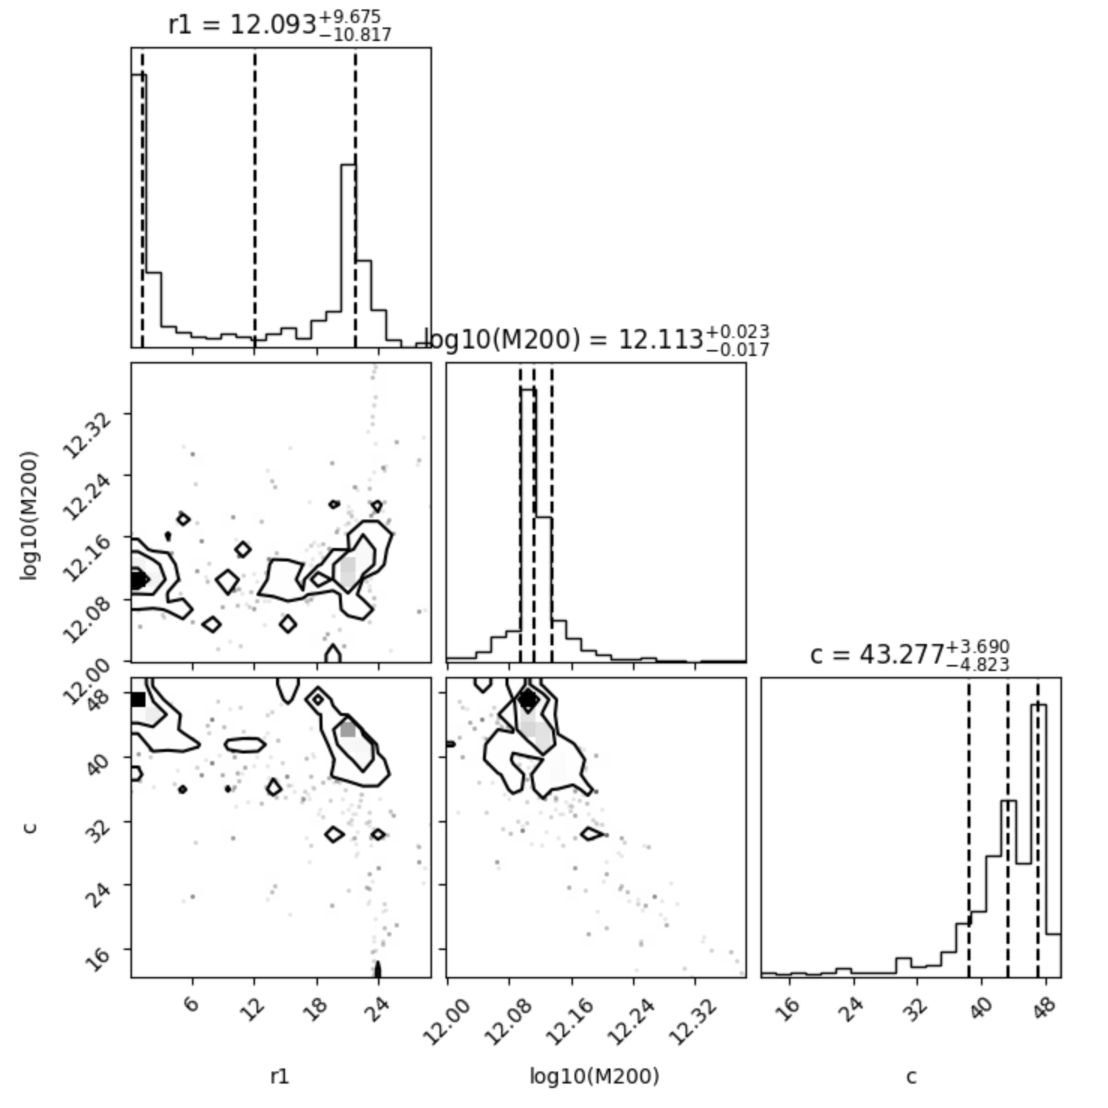

In [8]:
from IPython.display import Image, display
display(Image(filename="ScreenPics/3/Screen1.png", embed=True))
# first Tests Plots with corner where the Simulation was run for 200 steps with 8 walkers for "UGC09133_rotmod"

# 2: What? (What happened?)
## Describe what happened during your activities for the week.

During this week, the MCMC implementation was refined by extending the parameter space from two to three variables. In addition, the structure of the workflow was improved by separating the plotting routines from the location where the simulation results are stored. This allows a clearer distinction between the simulation stage and the subsequent analysis and visualization.

Furthermore, work is currently in progress to properly integrate the potential provided by the other group into the code. Their function has already been tested independently and successfully executed. The remaining task is to ensure a consistent integration with the variables and parameter definitions used in the current implementation.

# 3: So what? (What does it mean?)
## Describe your results


The use of a logarithmic parameterization for $M_{200}$ was necessary due to the wide range of possible values. Sampling directly in linear space would require exploring very large numerical scales, which would be computationally expensive. By using $\log M_{200}$, the parameter space can be explored more efficiently.

The expectation is that the MCMC chains should converge toward a stable region of parameter space. However, in the current results this convergence is not clearly observed. In particular, the posterior distribution of $r_1$ shows two distinct peaks, which indicates that the sampler has not yet settled into a single region.

One possible limitation is the relatively small number of steps used in the simulation. With only 200 steps, the chains may not have had sufficient time to fully explore the parameter space and reach convergence. Another indication of incomplete convergence is the appearance of isolated regions (“islands”) in some areas of the lower panels of the corner plots. These structures would likely disappear if the number of MCMC steps were increased to several thousand.

# 4. Now what? (What's next?)
## Plan for the next week

The next step is to include the baryonic potential $\Phi_b$, which has already been developed by the baryon team and provided for integration.

To incorporate the externally provided code into the current implementation, an adapter layer was introduced. This layer ensures compatibility between the variable naming conventions and the expected input types of both code bases. It performs the necessary mappings and type conversions so that the data structures and parameters match the interface requirements of the imported module.

Once this integration step is completed, the updated code will be shared with the entire research group. This will allow all members to run simulations and test the implementation on their own systems.

# 5. Bibliography
An LLM was used to improve the readability and clarity of the text in English.